# Workshop 1: LoRA Fine-Tuning with Qwen

Fine-tune a small language model using **LoRA** (Low-Rank Adaptation) on the Alpaca instruction dataset.  
We train only ~0.3% of parameters while the base model stays frozen.

**What you'll do:**
1. Load and format an instruction dataset  
2. Tokenize prompts  
3. Load a quantized base model (QLoRA)  
4. Attach a LoRA adapter  
5. Train with early stopping  
6. Plot train / validation / test loss curves  
7. Save and reload the adapter for inference

## 0. Install dependencies

Run once, then restart the kernel.

In [19]:
# Install the required packages
%pip install --upgrade torch torchvision torchaudio
%pip install matplotlib
%pip install transformers huggingface_hub
%pip install peft accelerate
%pip install datasets
%pip install accelerate bitsandbytes



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 28.1 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.2/684.2 kB 22.1 MB/s  0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.12.0
    Uninstalling torch-2.12.0:╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
      Successfully uninstalled torch-2.12.0━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [20]:
import os
import torch
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    default_data_collator,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import load_dataset, DatasetDict

## 2. Choose the base model

Change this one string to swap models — nothing else needs to change.

| Model | Size | Notes |
|---|---|---|
| `Qwen/Qwen2.5-0.5B-Instruct` | 0.5 B | Default — runs on CPU or any GPU |
| `Qwen/Qwen3.5-27B` | 27 B | Needs A10+ |
| `google/gemma-3-27b-it` | 27 B | Google Gemma instruction model |
| `mistralai/Mistral-7B-Instruct-v0.3` | 7 B | Original workshop default |

In [21]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

## 3. Prompt formatting

`build_messages` converts an Alpaca example into Qwen's native **ChatML** format
(`system / user / assistant` roles).  
The tokenizer's `apply_chat_template` will later render these into the correct special tokens.

In [22]:
import json

def build_messages(example, include_response=True):
    """Return a ChatML messages list for the given Alpaca example."""
    instruction = example["instruction"].strip()
    user_input  = example["input"].strip()
    output      = example["output"].strip()

    user_content = f"{instruction}\n\n{user_input}" if user_input else instruction

    messages = [
        {"role": "system",    "content": "You are a helpful assistant."},
        {"role": "user",      "content": user_content},
    ]
    if include_response:
        messages.append({"role": "assistant", "content": output})
    return messages


# Quick preview (tokenizer not needed — shows raw message structure)
sample = {
    "instruction": "Summarize the paragraph.",
    "input": "The Eiffel Tower is in Paris.",
    "output": "The Eiffel Tower is a Paris landmark."
}
print(json.dumps(build_messages(sample), indent=2))

[
  {
    "role": "system",
    "content": "You are a helpful assistant."
  },
  {
    "role": "user",
    "content": "Summarize the paragraph.\n\nThe Eiffel Tower is in Paris."
  },
  {
    "role": "assistant",
    "content": "The Eiffel Tower is a Paris landmark."
  }
]


## 4. Load dataset and create train / validation / test splits

We use 600 examples from `yahma/alpaca-cleaned` — enough to see meaningful learning in a workshop.

**Option B** (commented below): load your own local JSON or CSV file instead.

In [23]:
print("Loading dataset...")

# --- Option A: public HuggingFace dataset ---
raw_dataset   = load_dataset("yahma/alpaca-cleaned")
small_dataset = raw_dataset["train"].shuffle(seed=42).select(range(600))

# --- Option B: local JSON or CSV ---
# raw_dataset   = load_dataset("json", data_files="path/to/your_data.json")
# # or: raw_dataset = load_dataset("csv", data_files="path/to/your_data.csv")
# # Your file must have 'instruction', 'input', and 'output' columns.
# small_dataset = raw_dataset["train"]   # already a flat split

# --- Split: 80% train (Model sees these examples and updates weights) 
# / 10% val  (Evaluated during training to detect overfitting and trigger early stopping)
# / 10% test (Never seen until training is fully complete, the final honest measure and preventing data leakage)---
train_test = small_dataset.train_test_split(test_size=0.20, seed=42) # returns a dict with 'train' and 'test' keys, where 'test' is the 20% split.
valid_test = train_test["test"].train_test_split(test_size=0.50, seed=42) # splits the 20% 'test' from above into 10% val and 10% test (50% of the 20%)

data = DatasetDict({
    "train":      train_test["train"],
    "validation": valid_test["train"],
    "test":       valid_test["test"],
})

print(data)
# Expected: ~480 train / 60 validation / 60 test

Loading dataset...
DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 480
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 60
    })
    test: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 60
    })
})


In [24]:
# Export a sample so users can inspect the expected CSV format
#small_dataset.select(range(5)).to_csv("sample_format.csv", index=False)
#print("Saved sample_format.csv — open it to see the required columns: instruction, input, output")

# Quick preview of the first example (raw, before tokenization)
print(small_dataset[0])


{'output': 'Early, she left the party.', 'input': 'She left the party early', 'instruction': 'Rearrange the following sentence to make the sentence more interesting.'}


## 5. Tokenizer and tokenization

- `apply_chat_template` renders the ChatML messages into Qwen's special tokens (`<|im_start|>`, `<|im_end|>`, etc.)
- `max_length=512` — truncate/pad every sample to 512 tokens  
- `labels = input_ids` — full-sequence loss (prompt + response). See Section 5b for response-only masking.

In [25]:
print("Preparing tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True) # each LLM family has its own specialized tokenizer, so we load it from the same model name. The 'use_fast' option enables a faster Rust-based tokenizer implementation.

if tokenizer.pad_token is None: # some tokenizers don't have a pad token by default, which can cause issues during training. We set it to the end-of-sequence token (eos_token) since it's a common choice for causal language models.
    tokenizer.pad_token = tokenizer.eos_token


def tokenize_function(example): # this function will be applied to each example in the dataset to convert the raw text into token IDs that the model can understand.
    full_text = tokenizer.apply_chat_template( # this method takes the structured messages list from build_messages and formats it into a single string according to the ChatML format expected by the model. It handles the role tags and special tokens automatically.
        build_messages(example, include_response=True),
        tokenize=False,
        add_generation_prompt=False,
    )
    tokenized = tokenizer( # now we take the full formatted text and tokenize it into input IDs. We also set truncation and padding options to ensure all sequences are the same length (512 tokens in this case), which is important for batch processing during training. 
        full_text,
        truncation=True,
        max_length=512,
        padding="max_length",
    )
    tokenized["labels"] = tokenized["input_ids"].copy() # For causal language modeling, the labels are the same as the input IDs (the model learns to predict the next token in the sequence). We make a copy to avoid any issues with references.
    return tokenized


tokenized = data.map(tokenize_function, batched=False) # We apply the tokenize_function to each example in the dataset using the map method. Setting batched=False means we process one example at a time, which is simpler for this demonstration. The result is a new dataset where each example now contains tokenized input IDs and labels ready for training.
print("Tokenization complete.", tokenized)

Preparing tokenizer...
Tokenization complete. DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 480
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 60
    })
    test: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 60
    })
})


## 5b. Alternative tokenization: response-only masking

By default (Section 5), `labels = input_ids` — the model computes loss on **every token**, including the system/user prompt.

With **prompt masking**, labels for prompt tokens are set to `-100` so PyTorch's cross-entropy ignores them. Loss is computed **only on the assistant response tokens**.

| Approach | Loss computed on | When to use |
|---|---|---|
| Section 5 (no mask) | Prompt + response | Quick experiments, small datasets |
| Section 5b (masked) | Response only | Production fine-tuning, larger datasets |

To use this version, run the cell below **instead of** the `tokenize_function` in Section 5, then continue from Section 6.

In [26]:
def tokenize_function_masked(example):
    """Tokenize with prompt masking — loss is computed on assistant response tokens only."""
    full_text   = tokenizer.apply_chat_template( # this method takes the structured messages list from build_messages and formats it into a single string according to the ChatML format expected by the model. It handles the role tags and special tokens automatically.
        build_messages(example, include_response=True),
        tokenize=False,
        add_generation_prompt=False,
    )

    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=512,
        padding="max_length",
    )

    # We want to compute loss only on the assistant's response, not the user's prompt. To do this, we need to find out how many tokens the prompt takes up in the input_ids, so we can set those positions in the labels to -100 (mask) (which tells the loss function to ignore them). 

    prompt_text = tokenizer.apply_chat_template( # we generate the prompt text separately so we can find out how many tokens it takes and mask them in the labels.
        build_messages(example, include_response=False),
        tokenize=False,
        add_generation_prompt=True,   # ends just before the assistant turn
    )

    prompt_token_len = len(
        tokenizer(prompt_text, truncation=True, max_length=512)["input_ids"]
    ) # We tokenize the prompt separately to find out how many tokens it takes, so we know how many initial tokens to mask in the labels.


    labels = tokenized["input_ids"].copy()
    labels[:prompt_token_len] = [-100] * prompt_token_len  # ignore prompt tokens in loss
    tokenized["labels"] = labels
    return tokenized


tokenized = data.map(tokenize_function_masked, batched=False)
print("Tokenization with prompt masking complete.", tokenized)

Tokenization with prompt masking complete. DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 480
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 60
    })
    test: Dataset({
        features: ['output', 'input', 'instruction', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 60
    })
})


## 6. Load the base model with 4-bit quantization (QLoRA)

Weights are stored as 4-bit integers (~8× smaller in memory).  
Computation is still done in `bfloat16` for numerical stability.  
The base model weights are **frozen** — only the LoRA adapter will be trained.

In [27]:
use_cuda = torch.cuda.is_available()
print(f"Loading base model ({'CUDA' if use_cuda else 'CPU'})...")

if use_cuda:
    bnb_config = BitsAndBytesConfig( # this configuration tells the model to load in 4-bit precision, which reduces memory usage and speeds up training. 
        load_in_4bit=True, # enables loading the model in 4-bit precision, which reduces memory usage and speeds up training. This is particularly useful for large models that may not fit in GPU memory otherwise. 
        bnb_4bit_use_double_quant=True, # enables a technique called double quantization, which can improve the quality of 4-bit quantization by using an intermediate representation. 
        bnb_4bit_quant_type="nf4", # specifies the quantization type to use for 4-bit quantization. "nf4" stands for "normal float 4", which is a specific quantization scheme that can help preserve model accuracy while reducing memory usage.
        bnb_4bit_compute_dtype=torch.bfloat16, # sets the compute dtype for 4-bit quantization to bfloat16, which is a lower-precision format that can speed up training while maintaining accuracy.
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
    )
    base_model = prepare_model_for_kbit_training( # this function prepares the model for training with quantized weights (like our 4-bit model). It typically involves freezing certain layers and enabling gradient checkpointing to save memory during training.
        base_model,
        use_gradient_checkpointing=True,
       #gradient_checkpointing_kwargs={"use_reentrant": False}, # avoids PyTorch deprecation warning about reentrant checkpointing
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
    )

print("Base model loaded.")

Loading base model (CPU)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Base model loaded.


In [28]:
for name, _ in base_model.named_modules():
    print(name)


model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.act_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.act_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers.2
model.layers.2.self_attn
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp
model.layers.2.mlp.gate_proj
model.l

## 7. Attach the LoRA adapter

**`task_type`** tells PEFT what problem we are solving:

| task_type | Use for | Example models |
|---|---|---|
| `CAUSAL_LM` | Decoder-only text generation | GPT, LLaMA, Qwen, Mistral |
| `SEQ_2_SEQ_LM` | Encoder-decoder generation | T5, BART, FLAN-T5 |
| `SEQ_CLASSIFICATION` | Sentence/document classification | BERT, RoBERTa |
| `TOKEN_CLS` | Token-level labeling (e.g. NER) | BERT, DistilBERT |
| `QUESTION_ANSWERING` | Span extraction QA | BERT, ALBERT |

**`inference_mode=False`** builds the gradient graph for training.  
Set to `True` when loading the adapter for inference to save memory.

**`r=16`** — rank of each adapter matrix pair.  
**`lora_alpha=32`** — scales adapter output by `alpha/r = 2.0`.  
**`target_modules`** — attach adapters to these four attention projection layers.

In [29]:
# The task_type tells PEFT what kind of problem we are solving.
# Common values:
#   CAUSAL_LM         - decoder-only text generation (GPT, LLaMA, Mistral, Qwen)
#   SEQ_2_SEQ_LM      - encoder-decoder generation (T5, BART)
#   SEQ_CLASSIFICATION - sentence/document classification
#   TOKEN_CLS         - token-level classification (NER)
#   QUESTION_ANSWERING - span extraction QA
lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    inference_mode=False,   # True when loading for inference (saves memory)
    r=8, # the rank of the low-rank decomposition. A smaller r means fewer trainable parameters and more parameter sharing, which can be good for very small datasets or when you want to be very memory efficient. A larger r allows for more expressivity and can improve performance on larger datasets, but also increases the number of trainable parameters.
    lora_alpha=32, # the alpha parameter for LoRA scaling (alpha/r=2: The influence of the fine-tuning updates is doubled. )
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
# Expected: trainable params ~1.3M || all params ~500M || trainable% ~0.26%

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


## 8. (Optional) MultiEvalTrainer — track test loss as a full curve

Skip this cell entirely if you only want train/validation curves — Section 9
uses the standard `Trainer` by default, which already evaluates only the
dataset passed via `eval_dataset` (validation), no subclassing needed.

Run this cell if you also want a full **test loss curve** (not just a single
endpoint). The standard `Trainer` only evaluates one dataset at a time, so
`MultiEvalTrainer` overrides `evaluate()` to also run the test set at every
eval step. If you define it, swap it in for `Trainer` in Section 9 and pass
`test_dataset=tokenized["test"]`.

The `if eval_dataset is None` guard ensures test eval only runs during the
training loop, not on any manual `.evaluate()` calls.

In [30]:
track_test_loss = True  # set True and run Section 8, if you want a test loss curve too

class MultiEvalTrainer(Trainer):
    """Trainer that also evaluates the test set at every eval step."""

    def __init__(self, test_dataset=None, **kwargs):
        super().__init__(**kwargs)
        self._test_dataset = test_dataset

    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(
            eval_dataset=eval_dataset,
            ignore_keys=ignore_keys,
            metric_key_prefix=metric_key_prefix,
        )
        # Only run test eval during training-loop evals, not on explicit external calls
        if eval_dataset is None and self._test_dataset is not None:
            test_metrics = super().evaluate(
                eval_dataset=self._test_dataset,
                ignore_keys=ignore_keys,
                metric_key_prefix="test",
            )
            metrics.update(test_metrics)  # merge so test_loss appears in log_history entries
        return metrics

## 9. Training arguments and trainer setup

**Gradient accumulation:** `batch_size=1` × `accumulation_steps=16` → effective batch of 16 without holding all 16 in VRAM at once.

**Early stopping:** if validation loss doesn't improve for 3 consecutive eval checkpoints (every 5 steps = patience of 15 steps), training stops and the best checkpoint is restored.

Set `track_test_loss = True` below if you ran Section 8 and want a test loss
curve too; otherwise it builds a plain `Trainer` with train/validation only.

In [31]:
os.makedirs("workshop_outputs/lora-alpaca", exist_ok=True)

training_args = TrainingArguments(
    output_dir="workshop_outputs/lora-alpaca",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16, # Processes 16 mini-batches before one weight update. Effective batch size = 1 × 16 = 16. Saves GPU memory vs. one large batch.
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=5, # Evaluate val loss every 5 optimizer steps. Frequent enough to catch overfitting early.
    eval_strategy="steps",
    eval_steps=5,
    save_steps=5,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=use_cuda,
    gradient_checkpointing=use_cuda,                                    # enable on GPU
    gradient_checkpointing_kwargs={"use_reentrant": False} if use_cuda else {},
    optim="paged_adamw_32bit" if use_cuda else "adamw_torch",
    report_to="none",
)



trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=default_data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # Stop if val_loss fails to improve for 3 consecutive eval checkpoints (= 15 steps). Restores best checkpoint automatically.
)

if track_test_loss:  # Never evaluate on test during training, MultiEvalTrainer only logs test loss; no hyperparameter tuning against it.
    trainer = MultiEvalTrainer(test_dataset=tokenized["test"], **trainer_kwargs)
else:
    trainer = Trainer(**trainer_kwargs)

print(f"Trainer ready ({'with' if track_test_loss else 'without'} test loss tracking).")

Trainer ready (with test loss tracking).


## 10. Train!

In [32]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/elhambarezi/miniconda3/envs/1stWorkshop/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss
5,7.651650,1.932424
10,0.946244,0.375207
15,0.424540,0.372110
20,0.457432,0.369929
25,0.406765,0.368955
30,0.412397,0.368607


[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
/Users/elhambarezi/miniconda3/envs/1stWorkshop/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
/Users/elhambarezi/miniconda3/envs/1stWorkshop/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[transformers] early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
/Users/elhambarezi/miniconda3/envs/1stWorkshop/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_mem

TrainOutput(global_step=30, training_loss=1.7165045897165934, metrics={'train_runtime': 213.0645, 'train_samples_per_second': 2.253, 'train_steps_per_second': 0.141, 'total_flos': 529336746639360.0, 'train_loss': 1.7165045897165934, 'epoch': 1.0})

## 11. Plot train / validation (/ test) loss curves

**What to look for:**
- **Train loss (blue):** Should decrease steadily.  
- **Validation loss (orange):** Tracks train loss early, then plateaus. Rising sharply = overfitting.  
- **Test loss (red):** Only present if you used `MultiEvalTrainer` (Section 8). Should stay close to validation loss — a large gap means a non-representative split.

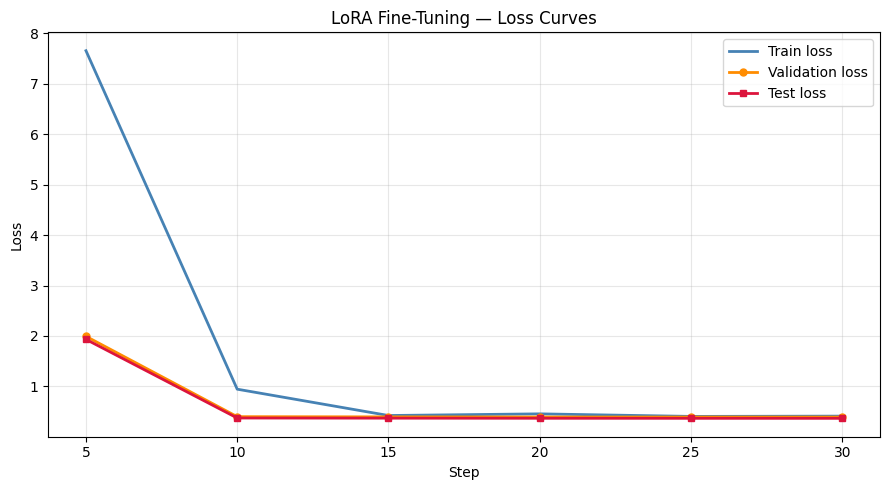

Loss plot saved to workshop_outputs/lora-alpaca/loss_curves.png


In [33]:
train_steps, train_losses = [], []
eval_steps,  eval_losses  = [], []
test_steps,  test_losses  = [], []

for entry in trainer.state.log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])
    if "test_loss" in entry:
        test_steps.append(entry["step"])
        test_losses.append(entry["test_loss"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_steps, train_losses, label="Train loss",      color="steelblue",  linewidth=2)
ax.plot(eval_steps,  eval_losses,  label="Validation loss", color="darkorange", linewidth=2, marker="o", markersize=5)
if test_losses:  # only present if MultiEvalTrainer (Section 8) was used
    ax.plot(test_steps, test_losses, label="Test loss", color="crimson", linewidth=2, marker="s", markersize=5)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("LoRA Fine-Tuning — Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

plot_path = "workshop_outputs/lora-alpaca/loss_curves.png"
fig.savefig(plot_path, dpi=150)
plt.show()
print(f"Loss plot saved to {plot_path}") 
# train loss must decrease steadily, otherwise LR too low or data misformatted.
# Validation loss should decrease in tandem with train loss, otherwise overfitting is occurring, and early stopping helps.
# test loss must match validation loss closely, otherwise split wasn't random or representative.

## 12. Save the LoRA adapter

Only the adapter weights are saved (~5 MB), not the full base model (~500 MB).  
Anyone with the base model can use your adapter file.

In [34]:
trainer.save_model("lora_alpaca_adapter")
print("Saved LoRA adapter to lora_alpaca_adapter/")
# Files created:
#   adapter_config.json        — records r, alpha, target_modules, base model name
#   adapter_model.safetensors  — the trained adapter weights
# The tokenizer is unchanged by LoRA training, so we don't save/reload it —
# Section 13 just loads it fresh from model_name.

Saved LoRA adapter to lora_alpaca_adapter/


## 13. Reload the adapter and run inference

In [35]:
if use_cuda:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    base_for_inference = AutoModelForCausalLM.from_pretrained(
        model_name, device_map="auto", quantization_config=bnb_config
    )
else:
    base_for_inference = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=torch.float32
    )

inference_model     = PeftModel.from_pretrained(base_for_inference, "lora_alpaca_adapter") # Anyone with the base model can use your adapter. Share a 5MB file, not a 500MB model.

inference_tokenizer = AutoTokenizer.from_pretrained(model_name)  # same tokenizer as training — never modified, so no need to save/reload it from the adapter dir
if inference_tokenizer.pad_token is None: # some tokenizers don't have a pad token by default, which can cause issues during training. We set it to the end-of-sequence token (eos_token) since it's a common choice for causal language models.
    inference_tokenizer.pad_token = inference_tokenizer.eos_token

test_example = data["test"][0]
prompt = inference_tokenizer.apply_chat_template(
    build_messages(test_example, include_response=False),
    tokenize=False,
    add_generation_prompt=True,   # appends <|im_start|>assistant\n so the model continues
)

inputs = inference_tokenizer(prompt, return_tensors="pt").to(base_for_inference.device)

max_new = 200 if use_cuda else 50
outputs = inference_model.generate(
    **inputs,
    max_new_tokens=max_new,
    do_sample=False,
)
print(inference_tokenizer.decode(outputs[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

system
You are a helpful assistant.
user
Describe the scene at a bustling farmers' market.
assistant
The scene at a bustling farmers' market is one of vibrant activity, with people from all walks of life gathered together to purchase fresh produce and other goods. The air is filled with the scent of freshly cut grass and the sound of birdsong as vendors


## 14. Extension ideas

- Swap `model_name` to `mistralai/Mistral-7B-Instruct-v0.3` and compare results  
- Use Option B to load your own instruction dataset  
- Increase `r` and `lora_alpha` — observe the effect on loss and adapter file size  
- Merge the adapter permanently: `model.merge_and_unload()` collapses LoRA into the base weights  
- Try `task_type="SEQ_CLASSIFICATION"` on a BERT model for text classification